# Initail Setup

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from one.api import ONE
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from iblatlas.regions import BrainRegions
from iblatlas.plots import plot_scalar_on_slice
from iblatlas.atlas import AllenAtlas
from iblatlas.flatmaps import FlatMap
from iblatlas.plots import plot_swanson_vector
from iblatlas.plots import plot_scalar_on_flatmap
from scipy import stats
from scipy.signal import butter, filtfilt
import pickle
import matplotlib as mpl
from brainbox.ephys_plots import image_fr_plot
from iblutil.numerical import bincount2D

In [8]:
# Candidate sessions:

# subject = "UCLA_037"
# eid = "bda2faf5-9563-4940-a80f-ce444259e47b"
# pid = "29418b18-4db6-436f-a85e-b0f1d38d2e62"

In [10]:
# Define Constants / Configuration
CONFIG = {
    'REVISION': '2024-05-06', 
    'TASK_EXCLUDE_WINDOW_PRE': 0.2, 
    'TASK_EXCLUDE_WINDOW_POST': 0.5,
    'LP_FILTER_HZ': 20,
    'MAX_SESSIONS_TO_PROCESS': None, 
    'CCG_BIN_SIZE': 0.001, 
    'CCG_WINDOW_SIZE': 0.2,
    'COUPLING_METHOD': 'sta', # 'correlation' or 'sta'
}

In [11]:
# Define and create project paths
base_path = Path(r"C:/Users/Experiment/Documents/Amirreza/SeqProject2026")
path_data = base_path / "data"
path_fig = base_path / "results" / "figures"
path_data_processed = path_data / "processed"
ibl_cache = path_data / 'raw'

# Create directories
for p in [ibl_cache, path_fig, path_data_processed]:
    p.mkdir(exist_ok=True, parents=True)

print(f"Directories ready. Cache: {ibl_cache}")

# Setup the ONE API with custom cache directory
try:
    one = ONE(base_url='https://openalyx.internationalbrainlab.org', password='international', silent=True, cache_dir=ibl_cache)
    print("ONE API initialized.")
except Exception as e:
    print(f"Error initializing ONE: {e}")

# Setup AllenAtlas
ba = AllenAtlas()

Directories ready. Cache: C:\Users\Experiment\Documents\Amirreza\SeqProject2026\data\raw
ONE API initialized.


# Session Selection, Download and Load

In [32]:
# Define the Probe Insertion ID (PID)
pid = "29418b18-4db6-436f-a85e-b0f1d38d2e62"
print(f"\nProcessing PID: {pid}")

# Initialize SpikeSortingLoader
ssl = SpikeSortingLoader(pid=pid, one=one, atlas=ba)
print(f"Session ID (EID): {ssl.eid}")
print(f"Probe Name: {ssl.pname}")

# Load Spiking Neural Data (Spikes, Clusters, Channels)
# load_spike_sorting() downloads and loads the data efficiently
spikes, clusters, channels = ssl.load_spike_sorting()

# IMPORTANT: Merge clusters with channel data to get brain region acronyms and coordinates
clusters = ssl.merge_clusters(spikes, clusters, channels)

print(f"Spikes loaded: {spikes.times.shape[0]} spikes")
if 'acronym' in clusters:
    print(f"Cluster regions found: {set(clusters.acronym)}")

# Load Trial Data using SessionLoader
sl = SessionLoader(eid=ssl.eid, one=one)
sl.load_trials()
print(f"Trials loaded. Found keys: {list(sl.trials.keys())}")
sl.load_wheel()
print(f"Wheel data loaded. Found keys: {list(sl.wheel.keys())}")
sl.load_pose(views=['left', 'right'])
print(f"Pose data loaded. Found keys: {list(sl.pose.keys())}")


Processing PID: 29418b18-4db6-436f-a85e-b0f1d38d2e62
Session ID (EID): bda2faf5-9563-4940-a80f-ce444259e47b
Probe Name: probe00
Spikes loaded: 20308805 spikes
Cluster regions found: {'VISp1', 'ENTm3', 'VISp2/3', 'VISpl4', 'VISp4', 'void', 'VISpl5'}


c:\Users\Experiment\anaconda3\envs\Seq2026\Lib\site-packages\one\util.py:436: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


Trials loaded. Found keys: ['goCueTrigger_times', 'intervals_bpod_0', 'intervals_bpod_1', 'quiescencePeriod', 'stimOffTrigger_times', 'stimOff_times', 'stimOnTrigger_times', 'goCue_times', 'response_times', 'choice', 'stimOn_times', 'contrastLeft', 'contrastRight', 'probabilityLeft', 'feedback_times', 'feedbackType', 'rewardVolume', 'firstMovement_times', 'intervals_0', 'intervals_1']
Wheel data loaded. Found keys: ['times', 'position', 'velocity', 'acceleration']


c:\Users\Experiment\anaconda3\envs\Seq2026\Lib\site-packages\one\util.py:436: ALFWarning: Multiple revisions: "", "2023-04-20"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
c:\Users\Experiment\anaconda3\envs\Seq2026\Lib\site-packages\one\util.py:436: ALFWarning: Multiple revisions: "2023-04-20", ""
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


Pose data loaded. Found keys: ['leftCamera', 'rightCamera']


In [38]:
# TODO: Access specific pose data and add to raster plot
# 
# sl.pose['leftCamera']

# Behavioural Data

In [19]:
reaction_time = trials['response_times'] - trials['stimOn_times']

correct_trial_idx = trials['feedbackType'] == 1
incorrect_trial_idx = trials['feedbackType'] == -1
correct_reaction_time = np.mean(reaction_time[correct_trial_idx])
incorrect_reaction_time = np.mean(reaction_time[incorrect_trial_idx])

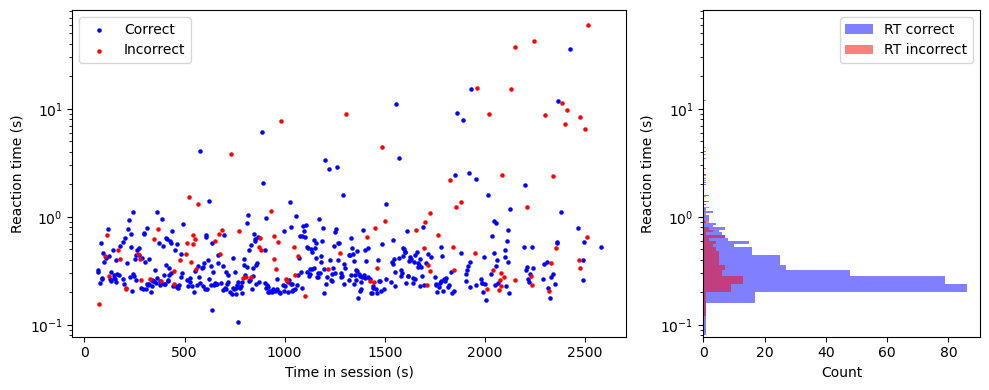

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [2, 1]})  # Adjust figsize as needed

# Scatter plot on the left (ax1)
ax1.scatter(trials['stimOn_times'][correct_trial_idx], reaction_time[correct_trial_idx], c='blue', s=5, label='Correct')
ax1.scatter(trials['stimOn_times'][incorrect_trial_idx], reaction_time[incorrect_trial_idx], c='red', s=5, label='Incorrect')
ax1.set_yscale("log")
ax1.set_xlabel('Time in session (s)')
ax1.set_ylabel('Reaction time (s)')
ax1.legend()

# Histogram on the right (ax2)
ax2.hist(reaction_time[correct_trial_idx], bins=np.linspace(0, 20, 500), color='blue', alpha=0.5, label='RT correct', orientation='horizontal')
ax2.hist(reaction_time[incorrect_trial_idx], bins=np.linspace(0, 20, 500), color='red', alpha=0.5, label='RT incorrect', orientation='horizontal')
ax2.legend()
ax2.set_xlabel('Count')
ax2.set_ylabel('Reaction time (s)')
ax2.set_yscale("log")
ax2.set_ylim(ax1.get_ylim())  # Sync y-axis limits with scatter plot

plt.tight_layout()  # Adjust spacing between subplots
#To see the output, run the code.

# Single unit Raster plot & PSTH

In [41]:
datasets = one.list_datasets(eid, collection='alf/probe*')
probe_labels = set(d.split('/')[1] for d in datasets)  # List the insertions

# You can find full details of a session's insertions using the following database query:
insertions = one.alyx.rest('insertions', 'list', session=eid)
probe_labels = [ins['name'] for ins in insertions]

files = one.load_collection(eid, f'alf/{probe_labels[0]}/pykilosort', download_only=True)

# Show where files have been downloaded to
print(f'Files downloaded to {files[0].parent}')

(S3) C:\Users\Experiment\Downloads\ONE\openalyx.internationalbrainlab.org\churchlandlab_ucla\Subjects\UCLA037\2022-02-10\001\alf\probe00\pykilosort\#2024-05-06#\_ibl_log.info_pykilosort.log: 100%|██████████| 531k/531k [00:00<00:00, 960kB/s]
(S3) C:\Users\Experiment\Downloads\ONE\openalyx.internationalbrainlab.org\churchlandlab_ucla\Subjects\UCLA037\2022-02-10\001\alf\probe00\pykilosort\#2024-05-06#\_kilosort_whitening.matrix.npy: 100%|██████████| 1.18M/1.18M [00:00<00:00, 3.41MB/s]
(S3) C:\Users\Experiment\Downloads\ONE\openalyx.internationalbrainlab.org\churchlandlab_ucla\Subjects\UCLA037\2022-02-10\001\alf\probe00\pykilosort\#2024-05-06#\_phy_spikes_subset.channels.npy: 100%|██████████| 14.5M/14.5M [00:01<00:00, 9.75MB/s]
(S3) C:\Users\Experiment\Downloads\ONE\openalyx.internationalbrainlab.org\churchlandlab_ucla\Subjects\UCLA037\2022-02-10\001\alf\probe00\pykilosort\#2024-05-06#\_phy_spikes_subset.spikes.npy: 100%|██████████| 905k/905k [00:00<00:00, 2.89MB/s]
(S3) C:\Users\Experimen

In [42]:
sl = SessionLoader(eid=eid, one=one)
sl.load_trials()

ssl = SpikeSortingLoader(one=one, pid=pid, atlas=ba)
spikes, clusters, channels = ssl.load_spike_sorting()
clusters = ssl.merge_clusters(spikes, clusters, channels)

c:\Users\Experiment\anaconda3\envs\Seq2026\Lib\site-packages\one\util.py:436: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


In [43]:
ssl.trials.keys()

AttributeError: 'SpikeSortingLoader' object has no attribute 'trials'

In [13]:
pid = "29418b18-4db6-436f-a85e-b0f1d38d2e62"
ssl = SpikeSortingLoader(pid=pid, one=one)
spikes, clusters, channels = ssl.load_spike_sorting()
clusters = ssl.merge_clusters(spikes, clusters, channels)
waveforms = ssl.load_spike_sorting_object('waveforms')  # loads in the template waveforms

(S3) C:\Users\Experiment\Downloads\ONE\openalyx.internationalbrainlab.org\churchlandlab_ucla\Subjects\UCLA037\2022-02-10\001\alf\probe00\pykilosort\#2024-05-06#\spikes.amps.npy: 100%|██████████| 162M/162M [00:06<00:00, 26.8MB/s] 
(S3) C:\Users\Experiment\Downloads\ONE\openalyx.internationalbrainlab.org\churchlandlab_ucla\Subjects\UCLA037\2022-02-10\001\alf\probe00\pykilosort\#2024-05-06#\spikes.clusters.npy: 100%|██████████| 81.2M/81.2M [00:02<00:00, 29.4MB/s]
(S3) C:\Users\Experiment\Downloads\ONE\openalyx.internationalbrainlab.org\churchlandlab_ucla\Subjects\UCLA037\2022-02-10\001\alf\probe00\pykilosort\#2024-05-06#\spikes.depths.npy: 100%|██████████| 162M/162M [00:03<00:00, 41.1MB/s] 
(S3) C:\Users\Experiment\Downloads\ONE\openalyx.internationalbrainlab.org\churchlandlab_ucla\Subjects\UCLA037\2022-02-10\001\alf\probe00\pykilosort\#2024-05-06#\spikes.times.npy: 100%|██████████| 162M/162M [00:04<00:00, 35.1MB/s] 
(S3) C:\Users\Experiment\Downloads\ONE\openalyx.internationalbrainlab.or

In [15]:
eid, pname = one.pid2eid(pid)
sl = SpikeSortingLoader(eid=eid, pname=pname, one=one)
spikes, clusters, channels = sl.load_spike_sorting()
clusters = sl.merge_clusters(spikes, clusters, channels)

In [40]:
# By default, if available, the data spikesorted with pykilosort is loaded.
# To find the spikesorting version that is loaded we can use
sl.collection

# To see all available spikesorted data for this probe insertion we can list the collections.
# N.B. ks2.5 matlab spikesorted data is stored in the alf/probe00 folder
sl.collections

# The following can be used to load a specific version of spikesorting

# pykilosort version
spikes, clusters, channels = sl.load_spike_sorting(spike_sorter='pykilosort')

# ks2.5 matlab version
spikes, clusters, channels = sl.load_spike_sorting(spike_sorter='')

AttributeError: 'SessionLoader' object has no attribute 'collection'

In [17]:
# The default spikes and cluster attributes loaded are:
# spikes - amps, clusters, depths, times
# cluster - channels, depths, metrics

#Other attributes can additionally be loaded in the following way
spikes, clusters, channels = sl.load_spike_sorting(dataset_types=['clusters.amps', 'spikes.samples'])
clusters = sl.merge_clusters(spikes, clusters, channels)

(S3) C:\Users\Experiment\Downloads\ONE\openalyx.internationalbrainlab.org\churchlandlab_ucla\Subjects\UCLA037\2022-02-10\001\alf\probe00\pykilosort\#2024-05-06#\spikes.samples.npy: 100%|██████████| 162M/162M [00:06<00:00, 26.7MB/s] 
(S3) C:\Users\Experiment\Downloads\ONE\openalyx.internationalbrainlab.org\churchlandlab_ucla\Subjects\UCLA037\2022-02-10\001\alf\probe00\pykilosort\#2024-05-06#\clusters.amps.npy: 100%|██████████| 8.58k/8.58k [00:00<00:00, 34.3kB/s]


In [20]:
time_bin = 0.05 # time bin in seconds
depth_bin = 10 # depth bin in um

# Remove any nan values
kp_idx = np.bitwise_and(~np.isnan(spikes['times']), ~np.isnan(spikes['depths']))

fr, time, depth = bincount2D(spikes['times'][kp_idx], spikes['depths'][kp_idx], time_bin, depth_bin)

In [21]:
good_clusterIDs = clusters['cluster_id'][clusters['label'] == 1]

In [23]:
good_clusterIDs.shape

(192,)

(S3) C:\Users\Experiment\Downloads\ONE\openalyx.internationalbrainlab.org\churchlandlab_ucla\Subjects\UCLA037\2022-02-10\001\alf\probe00\pykilosort\#2024-05-06#\drift.times.npy: 100%|██████████| 14.6k/14.6k [00:00<00:00, 67.0kB/s]
(S3) C:\Users\Experiment\Downloads\ONE\openalyx.internationalbrainlab.org\churchlandlab_ucla\Subjects\UCLA037\2022-02-10\001\alf\probe00\pykilosort\#2024-05-06#\drift.um.npy: 100%|██████████| 130k/130k [00:00<00:00, 298kB/s]


(<Figure size 1600x900 with 4 Axes>,
 array([[<Axes: title={'center': '2022-02-10_1_UCLA037_probe00, None \n20_308_805 spikes, 1_057 clusters'}>,
         <Axes: >],
        [<Axes: xlabel='time (secs)', ylabel='depth (um)'>,
         <Axes: title={'center': 'alf'}>]], dtype=object))

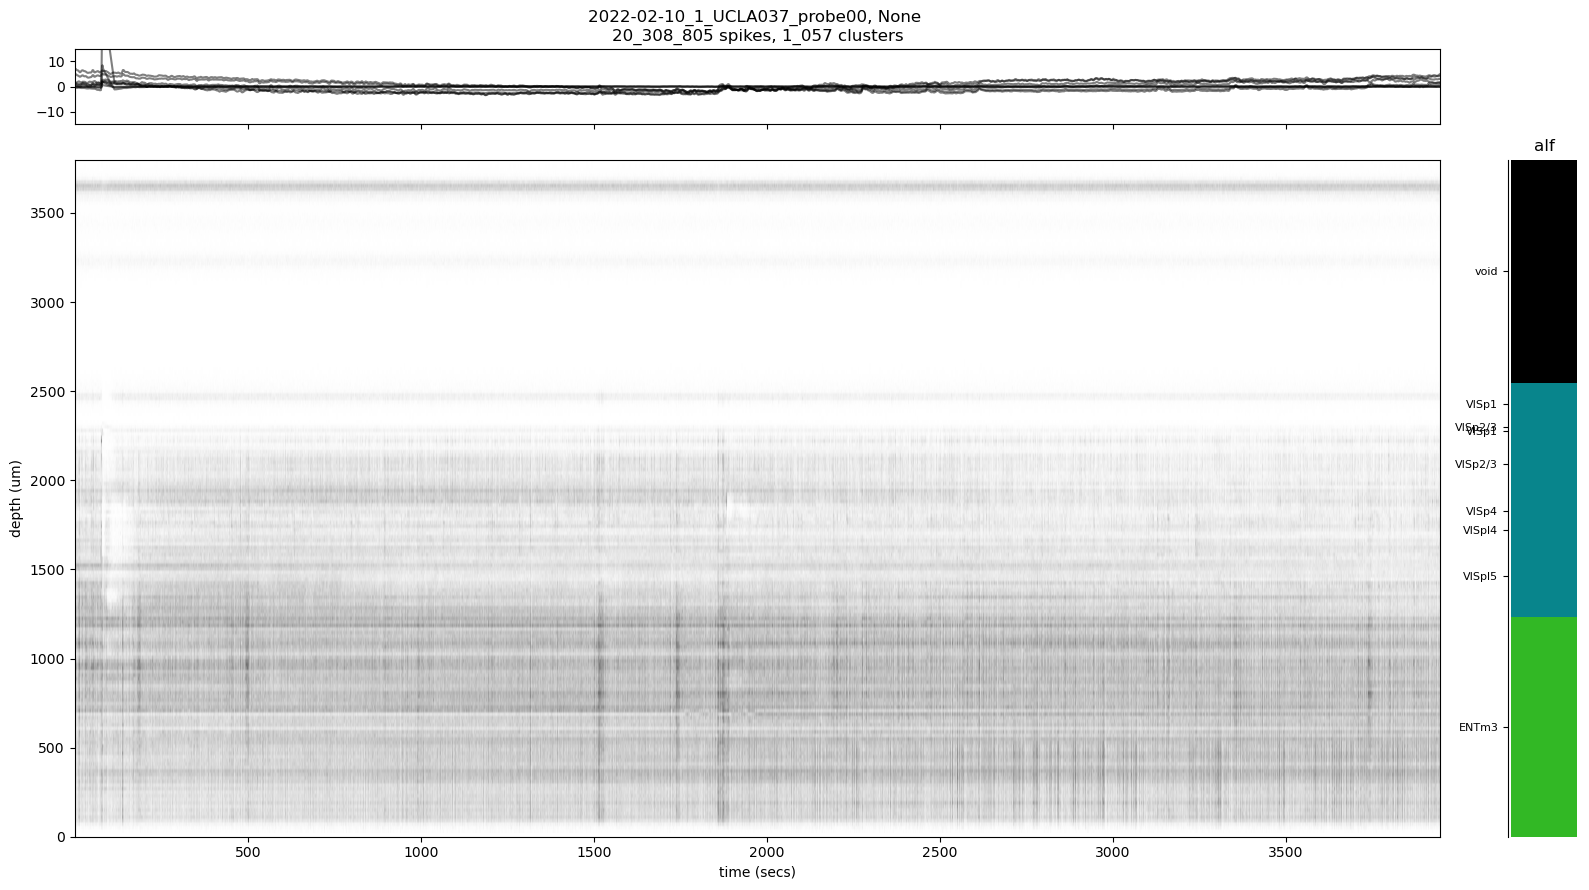

In [24]:
sl.raster(spikes, channels)